In [1]:
import numpy as np
import os, glob
import matplotlib.pyplot as plt
from netCDF4 import Dataset, MFDataset
from datetime import datetime, timedelta
import pandas as pd
import xarray as xr
import cftime
from sklearn.linear_model import LinearRegression
import warnings
from sklearn.metrics import r2_score
import time

In [2]:
warnings.simplefilter("ignore")

In [3]:
def get_satellite_predictors(X,var_sat):
    sat_vars = {'tbright':'brightness_temperature_clear',
                'pct_below':'percent_pixel_below_threshold'}
    #
    loadvar = np.empty([len(var_sat),len(X.variables['latitude'][:].data),
                           len(X.variables['longitude'][:].data)])
    #
    for i in np.arange(0,len(var_sat)):
        # print(var_sel)
        var_sel = var_sat[i]
        varname_sel = sat_vars[var_sel]
        ivar = X[varname_sel].squeeze()
        loadvar[i,:,:] = ivar
    return loadvar

In [4]:
def get_sst_predictors(X,var_sst):
    sst_vars = {'sst':'sea_surface_temperature'}
    loadvar = np.empty([len(sst_vars),len(X.variables['latitude'][:].data),
                        len(X.variables['longitude'][:].data)])
    for i in np.arange(0,len(var_sst)):
        var_sel = var_sst[i]
        varname_sel = sst_vars[var_sel]
        ivar = X[varname_sel].squeeze()
        loadvar[i,:,:] = ivar
    return loadvar

In [5]:
def get_derived_predictors(X,var_derived):
    derived_vars = {'shrg':'shear_generalized',
                'tanom':'temperature_anomaly',
                'hmax':'height_max',
                'wvel':'vertical_velocity_average'}
    derived_var_levels = {'shrg':[],
               'tanom':[300,400],
               'hmax':[],
               'wvel':[]}
    # 
    loadvar = np.empty([len(var_derived),len(X.variables['latitude'][:].data),
                           len(X.variables['longitude'][:].data)])
    #
    for i in np.arange(0,len(var_derived)):
        # print(var_sel)
        var_sel = var_derived[i]
        varname_sel = derived_vars[var_sel]
        lev_sel = derived_var_levels[var_sel]
        #print(varname_sel,lev_sel)
        # 
        # levels = boop.variables['level']
        if lev_sel:
            ivar = X[varname_sel].sel(level=lev_sel).mean(dim="level").squeeze()
        else:
            ivar = X[varname_sel].squeeze()
        loadvar[i,:,:] = ivar
    return loadvar

In [6]:
def get_model_predictors(X,var_model):
    model_vars = {'RHmd':'relative_humidity',
              'vortl':'vorticity',
              'divl':'divergence',
              'divu':'divergence'}
    model_var_levels = {'RHmd':[500,700],
                    'vortl':[850],
                    'divl':[850],
                    'divu':[200]}
    model_var_rad = {'RHmd':[0,1000],
                 'vortl':[0,1000],
                 'divl':[0,1000],
                 'divu':[0,1000]}
    # 
    loadvar = np.empty([len(var_model),len(X.variables['latitude'][:].data),
                           len(X.variables['longitude'][:].data)])
    #
    for i in np.arange(0,len(var_model)):
        # print(var_sel)
        var_sel = var_model[i]
        varname_sel = model_vars[var_sel]
        lev_sel = model_var_levels[var_sel]
        reg_sel = model_var_rad[var_sel]
        #print(varname_sel,lev_sel)
        # 
        # levels = boop.variables['level']
        if lev_sel:
            if reg_sel:
                ivar = X[varname_sel].sel(level=lev_sel,region=reg_sel).mean(dim=["level","region"]).squeeze()
            else:
                ivar = X[varname_sel].sel(level=lev_sel).mean(dim="level").squeeze()
        else:
            if reg_sel:
                ivar = X[varname_sel].sel(region=reg_sel).mean(dim="region").squeeze()
            else:
                ivar = X[varname_sel].squeeze()
            
        loadvar[i,:,:] = ivar
    return loadvar

In [7]:
def get_ground_truth(forecast_date):
    stormtest = '/mnt/tcnas08/cslocum/TCFPv4/devdat/v1p0/storm/1p00/'
    yr_sel = forecast_date.year
    mon_sel = forecast_date.month
    day_sel = forecast_date.day
    hr_sel = forecast_date.hour
    #
    mon_sel_str = str(mon_sel) if mon_sel > 9 else '0'+str(mon_sel)
    day_sel_str = str(day_sel) if day_sel > 9 else '0'+str(day_sel)
    hr_sel_str = str(hr_sel) if hr_sel > 9 else '0'+str(hr_sel)
    #
    fpath = stormtest+'{year}/{mon}{day}/'.format(year=yr_sel,
                                          mon = mon_sel_str,
                                          day = day_sel_str)
    fname = 'TCFP-devdat-verif-storm_v4r0_blend_s{year}{mon}{day}{hr}00000_e{year}{mon}{day}{hr}00000_*.nc'.format(year=yr_sel,
                                                            mon=mon_sel_str,day=day_sel_str,hr=hr_sel_str)
    #
    xdata = xr.open_mfdataset(fpath+fname)
    atcfids = xdata.atcfid
    ground_truth = xdata.storm_classifier
    return atcfids,ground_truth

In [8]:
datacat_dict = {'satellite':'sat',
                'storm':'storm',
                'derived':'deriv',
                'model':'model',
                'sst':'sst'}
#
datacat_vars = {'satellite':['tbright','pct_below'],
                'derived':['shrg','tanom','hmax','wvel'],
                'model':['RHmd','vortl','divl','divu'],
                'sst':['sst']}
#
data_cat = ['model','derived','satellite','sst']

In [9]:
start_date = '2016-01-01'
end_date = '2018-01-01'

In [10]:
days_back = 5
forecast_date = pd.date_range(start=start_date,end=end_date,freq='6H')

In [11]:
for iforecast in forecast_date:
    data_dates = iforecast - pd.Timedelta(days_back,'D')
    if np.mod(iforecast.day,7) == 0:
        #print('forecasting for ',iforecast,'; data from ',data_dates)
    #
    yr_sel = data_dates.year
    mon_sel = data_dates.month
    day_sel = data_dates.day
    hr_sel = data_dates.hour
    #
    mon_sel_str = str(mon_sel) if mon_sel > 9 else '0'+str(mon_sel)
    day_sel_str = str(day_sel) if day_sel > 9 else '0'+str(day_sel)
    hr_sel_str = str(hr_sel) if hr_sel > 9 else '0'+str(hr_sel)
    # Get ground truth
    atcfids,ground_truth = get_ground_truth(iforecast)
    atcfid_df = atcfids.to_dataframe()
    atcfid_df['Date'] = iforecast
    if iforecast == forecast_date[0]:
        ground_truths_ALL = ground_truth.values
        atcfid_ALL = atcfid_df
    else:
        ground_truths_ALL = np.concatenate([ground_truths_ALL,ground_truth.values],axis=0)
        atcfid_ALL = pd.concat([atcfid_ALL,atcfid_df])
    ## Now get predictors
    variables_list = []
    full_predictors = []
    for idata in data_cat:
        #print(idata)
        data_dir = '/mnt/tcnas08/cslocum/TCFPv4/devdat/v1p0/{datatype}/1p00/'.format(datatype=idata)
        fpath = data_dir+'{year}/{mon}{day}/'.format(year=yr_sel,mon = mon_sel_str,day = day_sel_str)
        #
        fname = 'TCFP-devdat-pred-{dcat}_v4r0_blend_s{year}{mon}{day}{hr}00000_e{year}{mon}{day}{hr}00000_*.nc'.format(dcat=datacat_dict[idata],
        year=yr_sel,mon=mon_sel_str,day=day_sel_str,hr=hr_sel_str)
        # 
        xdata = xr.open_mfdataset(fpath+fname)
        var_ALL = datacat_vars[idata]
        if idata == 'model':
            X_model = get_model_predictors(xdata,var_ALL)
        elif idata == 'derived':
            X_model = get_derived_predictors(xdata,var_ALL)
        elif idata == 'satellite':
            X_model = get_satellite_predictors(xdata,var_ALL)
        #
        elif idata == 'sst':
            X_model = get_sst_predictors(xdata,var_ALL)
        lat = xdata.variables['latitude'][:]
        lon = xdata.variables['longitude'][:]
        #
        variables_list = variables_list+var_ALL
        if idata == data_cat[0]:
            full_predictors = X_model
        else:
            full_predictors = np.append(full_predictors,X_model,axis=0)
    ##
    if iforecast == forecast_date[0]:
        full_predictors_ALL = full_predictors
    elif iforecast == forecast_date[1]:
        full_predictors_ALL = np.stack([full_predictors_ALL,full_predictors],axis=3)
    else:
        full_predictors_ALL = np.append(full_predictors_ALL,np.expand_dims(full_predictors,axis=3),axis=3)

forecasting for  2016-01-07 00:00:00 ; data from  2016-01-04 00:00:00
forecasting for  2016-01-07 06:00:00 ; data from  2016-01-04 06:00:00
forecasting for  2016-01-07 12:00:00 ; data from  2016-01-04 12:00:00
forecasting for  2016-01-07 18:00:00 ; data from  2016-01-04 18:00:00
forecasting for  2016-01-14 00:00:00 ; data from  2016-01-11 00:00:00
forecasting for  2016-01-14 06:00:00 ; data from  2016-01-11 06:00:00
forecasting for  2016-01-14 12:00:00 ; data from  2016-01-11 12:00:00
forecasting for  2016-01-14 18:00:00 ; data from  2016-01-11 18:00:00
forecasting for  2016-01-21 00:00:00 ; data from  2016-01-18 00:00:00
forecasting for  2016-01-21 06:00:00 ; data from  2016-01-18 06:00:00
forecasting for  2016-01-21 12:00:00 ; data from  2016-01-18 12:00:00
forecasting for  2016-01-21 18:00:00 ; data from  2016-01-18 18:00:00
forecasting for  2016-01-28 00:00:00 ; data from  2016-01-25 00:00:00
forecasting for  2016-01-28 06:00:00 ; data from  2016-01-25 06:00:00
forecasting for  201

In [12]:
xdata

<xarray.Dataset> Size: 264kB
Dimensions:                  (time: 1, latitude: 91, longitude: 360)
Coordinates:
  * time                     (time) object 8B 168435-11-04 00:00:00
  * latitude                 (latitude) float32 364B -45.0 -44.0 ... 44.0 45.0
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
Data variables:
    forecast_reference_time  object 8B ...
    sea_surface_temperature  (time, latitude, longitude) float64 262kB dask.array<chunksize=(1, 91, 360), meta=np.ndarray>
Attributes: (12/54)
    title:                      TCFP_devdat_pred_sst
    comment:                    Tropical Cyclone Formation Probability v4 Pre...
    summary:                    The NESDIS Operational Tropical Cyclone Forma...
    keywords:                   EARTH SCIENCE > ATMOSPHERE > WEATHER EVENTS >...
    Conventions:                CF-1.8, ACDD-1.3
    id:                         423c2941-ccdb-401f-877f-ed81a723b0b5
    ...                         ...
    date_metadata_modified:     2023-03-20T18:00:00.000Z
    analysis_time:              2016-03-29T00:00:00Z
    metadata_link:              TCFP-devdat-pred-sst_v4r0_blend_s201603290000...
    production_site:            COLOSTATE/CIRA > Cooperative Institute for Re...
    production_environment:     CentOS Linux release 7.8.2003 (Core)
    date_modified:              2024-01-23T22:27:44.739Z

In [13]:
ground_truths_ALL.shape

(365, 91, 360)

In [63]:
ntest = np.floor(full_predictors_ALL.shape[3]*0.2)
print(ntest)

73.0


In [91]:
print(full_predictors_ALL[:,:,:,:-int(ntest)].shape)
X_train = full_predictors_ALL[:,:,:,:-int(ntest)]
y_train = ground_truths_ALL[:-int(ntest),:,:]


(11, 46, 180, 292)


In [92]:
X_test = full_predictors_ALL[:,:,:,-int(ntest):]
y_test = ground_truths_ALL[-int(ntest):,:,:]

In [93]:
print(X_test.shape)
print(X_train.shape)

(11, 46, 180, 73)
(11, 46, 180, 292)


In [94]:
features = X_train.reshape(X_train.shape[0]*X_train.shape[1]*X_train.shape[2],X_train.shape[3])
print(features.transpose().shape)
#
labels = y_train.reshape(y_train.shape[0],y_train.shape[1]*y_train.shape[2])
print(labels.shape)

(292, 91080)
(292, 8280)


In [105]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, r2_score, mean_squared_error
import joblib

In [96]:
from joblib import parallel_backend

with parallel_backend('threading', n_jobs=6):
    model = RandomForestRegressor(n_jobs=6,n_estimators=10)
    start_time = time.time()
    #print('start time ',start_time)
    model.fit(features.transpose(),labels)
    end_time = time.time()

print(end_time - start_time)

5461.47688293457


In [106]:
joblib.dump(model, "test_rf_model.pkl") 

['test_rf_model.pkl']

In [98]:
print(datetime.fromtimestamp(start_time).strftime('%c'))
print(datetime.fromtimestamp(end_time).strftime('%c'))


Wed Aug  7 21:32:41 2024
Wed Aug  7 23:03:42 2024


In [99]:
X_test.shape
lon.shape

(360,)

In [100]:
boop = model.predict(X_test.reshape(X_test.shape[0]*X_test.shape[1]*X_test.shape[2],
                                    X_test.shape[3]).transpose())

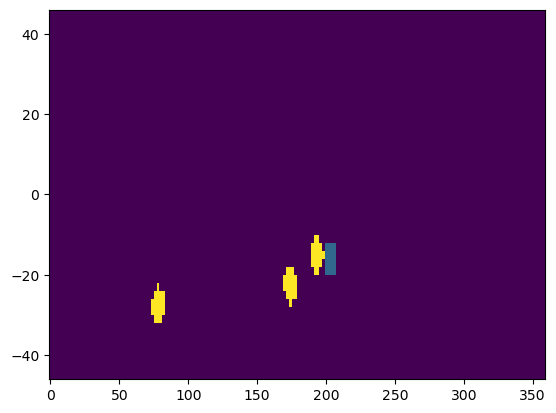

In [103]:
plot_boop = boop.reshape(y_test.shape[0],y_test.shape[1],y_test.shape[2])
plot_boop.shape
plt.pcolormesh(lon[::2],lat[::2],plot_boop[2,:,:])
#plt.colorbar()

TypeError: Dimensions of C (46, 180) should be one smaller than X(360) and Y(91) while using shading='flat' see help(pcolormesh)

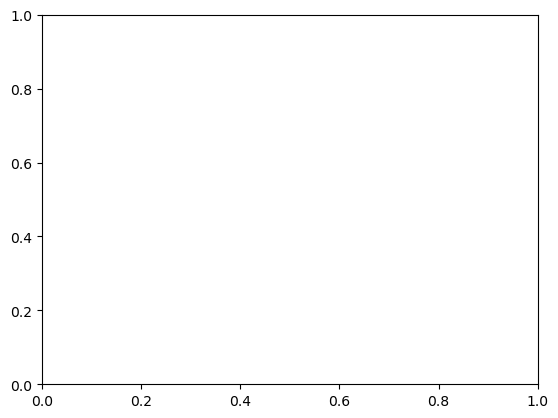

In [102]:
plt.pcolormesh(lon,lat,y_test[3,:,:])
plt.colorbar()

In [104]:
model.score(features.transpose(),labels)
r2_score(y_test.reshape(y_test.shape[0],y_test.shape[1]*y_test.shape[2]),boop)

0.9319141129641729

In [90]:
y_test.shape
#boop.shape

(73, 23, 90)

In [ ]:
test_reshape = features.reshape(full_predictors_ALL.shape[0],full_predictors_ALL.shape[1],
                                     full_predictors_ALL.shape[2],full_predictors_ALL.shape[3])


In [ ]:
fig11,ax11 = plt.subplots(1,1,figsize=(8,5))
pcm1 = ax11.pcolormesh(lon,lat,test_reshape[10,:,:,1].squeeze(),cmap='magma')
fig11.colorbar(pcm1)

In [ ]:
fig1,ax1 = plt.subplots(1,1,figsize=(8,5))
pcm = ax1.pcolormesh(lon,lat,full_predictors_ALL[10,:,:,1].squeeze(),cmap='magma')
fig1.colorbar(pcm)

In [107]:
mload = joblib.load("test_rf_model.pkl")

In [112]:
doopy = mload.predict(X_test.reshape(X_test.shape[0]*X_test.shape[1]*X_test.shape[2],
                                    X_test.shape[3]).transpose())

In [110]:
mload.score(features.transpose(),labels)

0.9925604070400957

In [113]:
r2_score(y_test.reshape(y_test.shape[0],y_test.shape[1]*y_test.shape[2]),doopy)

0.9319141129641729